In [20]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout


In [6]:
import pandas as pd

df = pd.read_csv("weather.csv")
print(df.head())

   MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine WindGustDir  \
0      8.0     24.3       0.0          3.4       6.3          NW   
1     14.0     26.9       3.6          4.4       9.7         ENE   
2     13.7     23.4       3.6          5.8       3.3          NW   
3     13.3     15.5      39.8          7.2       9.1          NW   
4      7.6     16.1       2.8          5.6      10.6         SSE   

   WindGustSpeed WindDir9am WindDir3pm  WindSpeed9am  ...  Humidity3pm  \
0           30.0         SW         NW           6.0  ...           29   
1           39.0          E          W           4.0  ...           36   
2           85.0          N        NNE           6.0  ...           69   
3           54.0        WNW          W          30.0  ...           56   
4           50.0        SSE        ESE          20.0  ...           49   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1019.7       1015.0         7         7     14.4     23.6 

In [16]:
drop_cols = [
    'Date',
    'Location',
    'WindGustDir',
    'WindDir9am',
    'WindDir3pm',
    'RISK_MM'
]

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)



In [17]:
# ==========================================
# HANDLE MISSING VALUES
# ==========================================

for col in df.columns:

    if df[col].dtype == 'object':

        df[col].fillna(
            df[col].mode()[0],
            inplace=True
        )

    else:

        df[col].fillna(
            df[col].mean(),
            inplace=True
        )

/tmp/ipykernel_995/437015701.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(
/tmp/ipykernel_995/437015701.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inpla

In [21]:
encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = encoder.fit_transform(df[col])

target = 'RainTomorrow'

X = df.drop(target, axis=1)

y = df[target]

scaler = MinMaxScaler()

X = scaler.fit_transform(X)



In [23]:
sequence_length = 7

X_seq = []
y_seq = []

for i in range(sequence_length, len(X)):

    X_seq.append(
        X[i-sequence_length:i]
    )

    y_seq.append(
        y.iloc[i]
    )

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence Shape:", X_seq.shape)

Sequence Shape: (359, 7, 17)


In [24]:

split = int(0.8 * len(X_seq))

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

print(X_train.shape)
print(X_test.shape)


(287, 7, 17)
(72, 7, 17)


In [25]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
print("\nLSTM MODEL")
lstm_model.summary()


LSTM MODEL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.8035 - loss: 0.5152 - val_accuracy: 0.8448 - val_loss: 0.4315
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8122 - loss: 0.5162 - val_accuracy: 0.8448 - val_loss: 0.4335
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8122 - loss: 0.4899 - val_accuracy: 0.8448 - val_loss: 0.4449
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8122 - loss: 0.4843 - val_accuracy: 0.8448 - val_loss: 0.4421
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8122 - loss: 0.4865 - val_accuracy: 0.8448 - val_loss: 0.4395
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8122 - loss: 0.4870 - val_accuracy: 0.8448 - val_loss: 0.4310
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8122 - loss: 0.4935 - val_accuracy: 0.8448 - val_loss: 0.4438
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8122 - loss: 0.4836 - val_accuracy: 0.8448 - val_

In [28]:

lstm_pred = lstm_model.predict(X_test)

lstm_pred = (
    lstm_pred > 0.5
).astype(int)

lstm_acc = accuracy_score(
    y_test,
    lstm_pred
)

print("\nLSTM Accuracy =", lstm_acc)

print(
    classification_report(
        y_test,
        lstm_pred
    )
)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step

LSTM Accuracy = 0.8611111111111112
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        62
           1       0.00      0.00      0.00        10

    accuracy                           0.86        72
   macro avg       0.43      0.50      0.46        72
weighted avg       0.74      0.86      0.80        72



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
bilstm_model = Sequential()

bilstm_model.add(
    Bidirectional(
        LSTM(
            64
        ),
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

bilstm_model.add(
    Dropout(0.2)
)

bilstm_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nBi-LSTM MODEL")
bilstm_model.summary()


Bi-LSTM MODEL


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        41,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,113 (164.50 KB)

 Trainable params: 42,113 (164.50 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:

history_bilstm = bilstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.7555 - loss: 0.5485 - val_accuracy: 0.8448 - val_loss: 0.4322
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8122 - loss: 0.4828 - val_accuracy: 0.8448 - val_loss: 0.4457
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8122 - loss: 0.4856 - val_accuracy: 0.8448 - val_loss: 0.4415
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8122 - loss: 0.4843 - val_accuracy: 0.8448 - val_loss: 0.4351
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8122 - loss: 0.4856 - val_accuracy: 0.8448 - val_loss: 0.4357
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8122 - loss: 0.4837 - val_accuracy: 0.8448 - val_loss: 0.4315
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8122 - loss: 0.4797 - val_accuracy: 0.8448 - val_loss: 0.4349
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8122 - loss: 0.4799 - val_accuracy: 0.8448 - v

In [31]:
bilstm_pred = bilstm_model.predict(
    X_test
)

bilstm_pred = (
    bilstm_pred > 0.5
).astype(int)

bilstm_acc = accuracy_score(
    y_test,
    bilstm_pred
)

print("\nBi-LSTM Accuracy =", bilstm_acc)

print(
    classification_report(
        y_test,
        bilstm_pred
    )
)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step

Bi-LSTM Accuracy = 0.8611111111111112
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        62
           1       0.00      0.00      0.00        10

    accuracy                           0.86        72
   macro avg       0.43      0.50      0.46        72
weighted avg       0.74      0.86      0.80        72



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
print("\n========================")
print("MODEL COMPARISON")
print("========================")

print("LSTM Accuracy   :", lstm_acc)
print("BiLSTM Accuracy :", bilstm_acc)



MODEL COMPARISON
LSTM Accuracy   : 0.8611111111111112
BiLSTM Accuracy : 0.8611111111111112


In [33]:
print("\nLSTM Confusion Matrix")
print(
    confusion_matrix(
        y_test,
        lstm_pred
    )
)

print("\nBiLSTM Confusion Matrix")
print(
    confusion_matrix(
        y_test,
        bilstm_pred
    )
)



LSTM Confusion Matrix
[[62  0]
 [10  0]]

BiLSTM Confusion Matrix
[[62  0]
 [10  0]]


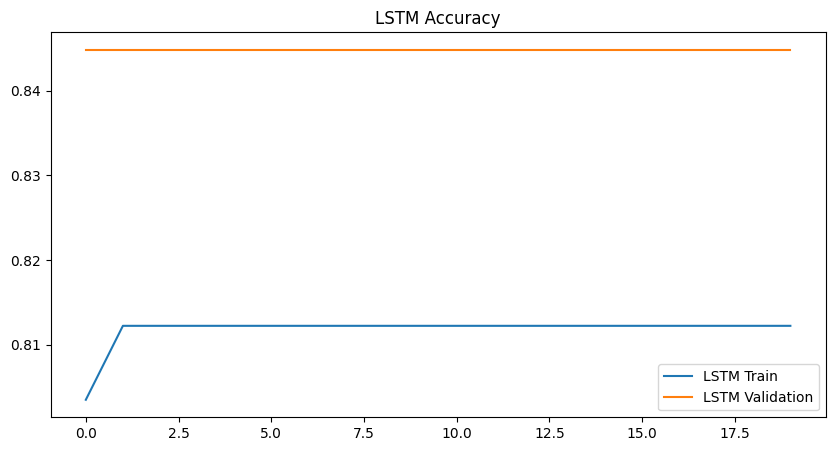

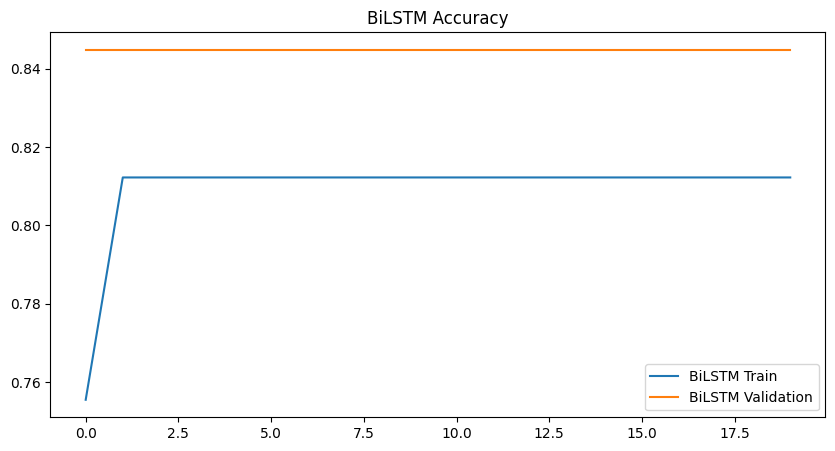

In [35]:

plt.figure(figsize=(10,5))

plt.plot(
    history_lstm.history['accuracy'],
    label='LSTM Train'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM Validation'
)

plt.legend()
plt.title("LSTM Accuracy")
plt.show()

plt.figure(figsize=(10,5))

plt.plot(
    history_bilstm.history['accuracy'],
    label='BiLSTM Train'
)

plt.plot(
    history_bilstm.history['val_accuracy'],
    label='BiLSTM Validation'
)

plt.legend()
plt.title("BiLSTM Accuracy")
plt.show()



In [36]:
# ==========================================
# PREDICT NEXT DAY RAIN
# ==========================================

sample = X_seq[-1]

sample = sample.reshape(
    1,
    sample.shape[0],
    sample.shape[1]
)

prediction = bilstm_model.predict(sample)

if prediction[0][0] > 0.5:
    print("\nPrediction: Rain Tomorrow")
else:
    print("\nPrediction: No Rain Tomorrow")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Prediction: No Rain Tomorrow
